# Imports

In [ ]:
# =========================
# Install dependencies
# =========================

!pip install -q prompt-baker
!pip install -q langchain langgraph langchain-core langchain-groq
!pip install -q pandas matplotlib

# Optional but useful in Colab
!pip install -q python-dotenv

In [1]:
from __future__ import annotations
import os
from pathlib import Path
from typing import Any

from prompt_baker import ChatModelSpec, OptimizerConfig, PromptBakerOptimizer
from prompt_baker.types import CompletionFn

from langchain_groq import ChatGroq
from langchain.tools import tool
from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
import os
import pandas as pd

from langchain_groq import ChatGroq

/opt/miniconda3/envs/llm/lib/python3.11/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
os.environ["GROQ_API_KEY"] = "groq-api-key" 

# Create LLM calls

In [3]:
def heuristic_completion(system_prompt: str, user_prompt: str) -> str:
    del system_prompt
    text = user_prompt.lower()
    positive_words = {"love", "amazing", "great", "helpful", "inspiring", "recommend"}
    negative_words = {"cold", "tasteless", "regret", "waste", "crashes", "dirty", "terrible", "rude"}
    pos = sum(word in text for word in positive_words)
    neg = sum(word in text for word in negative_words)
    return "positive" if pos >= neg else "negative"

In [4]:
def groq_llm_completion(system_prompt: str, user_prompt: str) -> str:

    llm_groq = ChatGroq(
        model="llama-3.3-70b-versatile"
    )
    agent = create_agent(llm_groq,system_prompt=system_prompt)
    
    response = agent.invoke(
        {"messages": [("user", user_prompt )]}
    )
    return response['messages'][-1].content

### List down all models with their completion functions

In [5]:
models = [
    ChatModelSpec(
        name="heuristic-default",
        completion_fn=heuristic_completion,
    ),
    ChatModelSpec(
        name="model-groq",
        completion_fn=groq_llm_completion
    )
]

### configure Genetic Algorithm optimizer, its population size, if you are not sure keep it default.

In [6]:
config = OptimizerConfig(
    task_type="classification",
    metric="accuracy",
    generations=8,
    population_size=4,
    token_length_optimisation=True,
)

### Initiate optimiser and ready to start "baking of the raw prompt"

In [7]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage



def paraphraser__groq_completion_fn(prompt: str) -> str:
    llm_groq_paraphraser = ChatGroq(
        model="llama-3.3-70b-versatile"
    )
    response = llm_groq_paraphraser.invoke(
        [
            SystemMessage(
                content=(
                    "You are an expert prompt engineer specialized "
                    "in paraphrasing and optimizing prompts."
                )
            ),
            HumanMessage(content=prompt),
        ]
    )

    return response.content.strip()

In [8]:
optimizer = PromptBakerOptimizer(
    model_specs=models,
    system_prompts=[
        "You are a sentiment classifier. Return only one word: positive or negative.",
        "Classify sentiment in strict format. Output exactly positive or negative.",
    ],
    user_prompts=[
        "Classify sentiment of this text: {input}",
        "Determine if the sentiment is positive or negative.\nText: {input}",
    ],
    paraphrase_completion_fn=paraphraser__groq_completion_fn,
    config=config,
    run_dir="logs"
)

In [9]:
csv_path = "benchmark_sentiment.csv"

### Let's start the baking process(optimize) of prompt and keep it running overninght or some days in server

In [10]:
best = optimizer.optimize(csv_path,verbose=True)
print("Best candidate:")
print(best)
print(f"Run logs: {optimizer.logger.run_dir}")

Baking process started ... 📄📄📄📄📄 ➜ 🥣 ➜ ♨️🔥🔥🔥



Generations:   0%|          | 0/8 [00:00<?, ?it/s]

Generation 1 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

Generation 2 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

Generation 3 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

...

Generation 5 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

Generation 6 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

Generation 7 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

Generation 8 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

🍞 Prompt model combination baked(optimized) successfully ✨

Best candidate:
CandidateGene(system_prompt='Classify sentiment in strict format. Output exactly positive or negative.', user_prompt='Classify sentiment of this text: {input}', model_name='model-groq', score=0.9991525, metrics={'base_score': 1.0, 'final_score': 0.9991525}, metadata={'system_original_prompt': 'Classify sentiment in strict format. Output exactly positive or negative.', 'system_paraphrased_prompt': 'Classify sentiment in strict format. Output exactly positive or negative.', 'system_variant_type': 'original', 'user_original_prompt': 'Classify sentiment of this text: {input}', 'user_paraphrased_prompt': 'Classify sentiment of this text: {input}', 'user_variant_type': 'original'})
Run logs: logs/run_20260511_134535


### Note: While baking in progress keep on checking how much prompt is cooked. `Keep on copy the log file some time and transfer it in local and see how much cooking is done`

# Visualisation

#### Now while code is running in any server take log files and in local copy log files from `run_dir="logs"` in `optimizer` and run this code for Visualisation `plot_progress`

In [11]:
from prompt_baker.visualizer import plot_progress

In [12]:
plot_file = plot_progress('logs')#(optimizer.logger.run_dir)
print(f"Progress plot: {plot_file}")

Progress plot: logs/progress.png


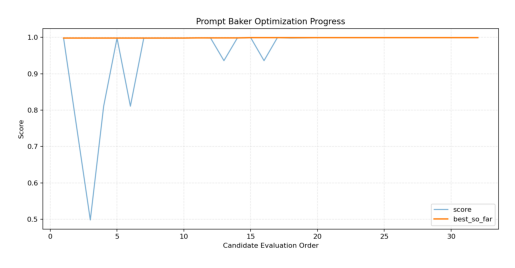

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('logs/progress.png')
plt.imshow(img)
plt.axis('off') # Hide the X and Y axes
plt.show()

### Once baking is done get the baked version of raw prompt. more time you keep baking with different parameters in population size, ... config params different results you will receive.

## Meanwhile you also can print reports like below to see which prompt,model and parameter(in case you want to explore just create custom generation function that way. see `cat_dog_rag.ipynb` or `cat_dog_rag.py` for more )

In [14]:
from prompt_baker.visualizer import create_scores_csv

In [15]:
create_scores_csv('logs',"generated_report_sentiment_classifier.csv")

PosixPath('generated_report_sentiment_classifier.csv')

In [25]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

In [26]:
pd.read_csv("generated_report_sentiment_classifier.csv").iloc[-5:-1]

,timestamp,generation,candidate_idx,score,base_score,final_score,model_name,system_prompt,user_prompt,system_original_prompt,system_paraphrased_prompt,user_original_prompt,user_paraphrased_prompt
27,2026-05-11T13:51:56.089718+00:00,3,0,0.935910,0.9375,0.935910,model-groq,Classify sentiment in strict format. Output exactly positive or negative.,Classify sentiment: positive or negative. Text: {input}\n\nOriginal prompt:\nDetermine if the sentiment is positive or negative.\nText: {input},Classify sentiment in strict format. Output exactly positive or negative.,Classify sentiment in strict format. Output exactly positive or negative.,Determine if the sentiment is positive or negative.\nText: {input},Classify sentiment: positive or negative. Text: {input}\n\nOriginal prompt:\nDetermine if the sentiment is positive or negative.\nText: {input}
28,2026-05-11T13:47:11.538465+00:00,1,1,0.810797,0.8125,0.810797,heuristic-default,"Classify sentiment as ""positive"" or ""negative"".\n\nOriginal prompt:\nYou are a sentiment classifier. Return only one word: positive or negative.",Classify sentiment: {input}\n\nOriginal prompt:\nClassify sentiment of this text: {input},You are a sentiment classifier. Return only one word: positive or negative.,"Classify sentiment as ""positive"" or ""negative"".\n\nOriginal prompt:\nYou are a sentiment classifier. Return only one word: positive or negative.",Classify sentiment of this text: {input},Classify sentiment: {input}\n\nOriginal prompt:\nClassify sentiment of this text: {input}
29,2026-05-11T13:46:31.386077+00:00,0,3,0.810797,0.8125,0.810797,heuristic-default,"Classify sentiment as ""positive"" or ""negative"".\n\nOriginal prompt:\nYou are a sentiment classifier. Return only one word: positive or negative.",Classify sentiment: {input}\n\nOriginal prompt:\nClassify sentiment of this text: {input},You are a sentiment classifier. Return only one word: positive or negative.,"Classify sentiment as ""positive"" or ""negative"".\n\nOriginal prompt:\nYou are a sentiment classifier. Return only one word: positive or negative.",Classify sentiment of this text: {input},Classify sentiment: {input}\n\nOriginal prompt:\nClassify sentiment of this text: {input}
30,2026-05-11T13:45:52.259768+00:00,0,1,0.747885,0.7500,0.747885,model-groq,"Classify the sentiment of the given input and respond with a single word indicating whether it is ""positive"" or ""negative"".\n\nOriginal prompt:\nYou are a sentiment classifier. Return only one word: positive or negative.",Determine if the sentiment is positive or negative.\nText: {input},You are a sentiment classifier. Return only one word: positive or negative.,"Classify the sentiment of the given input and respond with a single word indicating whether it is ""positive"" or ""negative"".\n\nOriginal prompt:\nYou are a sentiment classifier. Return only one word: positive or negative.",Determine if the sentiment is positive or negative.\nText: {input},Determine if the sentiment is positive or negative.\nText: {input}


### You can see now which things are causing improvement with minimum experementation(searching over all possible cases)